# Stage 2 — Healthy vs Symptomatic

二分類：`healthy` vs `symptomatic`（只用 non-covid 樣本）

特徵：516 維（512 HeAR + age + gender + respiratory + fever）

## Imports

In [1]:
import os
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report
from utils import plot_confusion_matrix

os.makedirs('checkpoints', exist_ok=True)

## Prepare Data

In [2]:
EMB_COLS  = [f'emb_{i}' for i in range(512)]
CLIN_COLS = ['age', 'gender_encoded', 'respiratory_condition', 'fever_muscle_pain']
FEATURES  = EMB_COLS + CLIN_COLS  # 516 維

df = pd.read_csv('data/prepared_train_hear.csv')
df = df[df['label'].isin(['healthy', 'symptomatic'])].copy()

df['label'] = df['label']

X = np.array(df[FEATURES], dtype=np.float32)
encoder = LabelEncoder()
y = encoder.fit_transform(df['label'])

print('classes:', encoder.classes_)
print('label 分佈:')
print(df['label'].value_counts())
print('X.shape:', X.shape)

indices = np.arange(len(y))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=y
)
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

classes: ['healthy' 'symptomatic']
label 分佈:
label
symptomatic    750
healthy        710
Name: count, dtype: int64
X.shape: (1460, 516)
X_train: (1168, 516), X_test: (292, 516)


## 5-Fold Cross Validation

K-FOLD CROSS VALIDATION RESULTS FOR 5 FOLDS
--------------------------------------------
|         | Train Accuracy | Test Accuracy |
--------------------------------------------
| Fold 0  |       73.12 % |       75.68 % |
| Fold 1  |       74.23 % |       69.18 % |
| Fold 2  |       73.89 % |       70.55 % |
| Fold 3  |       75.09 % |       65.75 % |
| Fold 4  |       73.29 % |       72.95 % |
--------------------------------------------
| Average |       73.92 % |       70.82 % |
| Std Dev |       0.71 % |       3.37 % |

              precision    recall  f1-score   support

     healthy       0.72      0.78      0.75       149
 symptomatic       0.75      0.68      0.71       143

    accuracy                           0.73       292
   macro avg       0.73      0.73      0.73       292
weighted avg       0.73      0.73      0.73       292



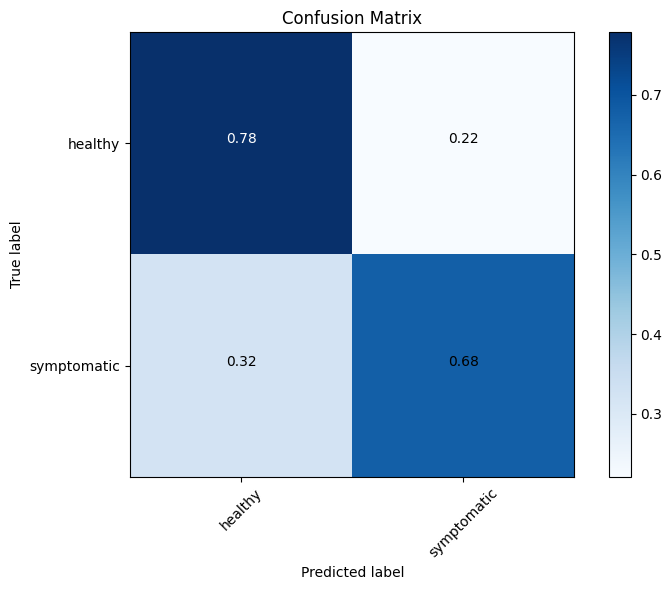

In [3]:
k_folds = 5
kfold   = KFold(n_splits=k_folds, shuffle=True, random_state=42)
results_train, results_test = [], []
last_preds, last_labels = None, None

print(f'K-FOLD CROSS VALIDATION RESULTS FOR {k_folds} FOLDS')
print('--------------------------------------------')
print('|         | Train Accuracy | Test Accuracy |')
print('--------------------------------------------')

for fold, (tr_ids, te_ids) in enumerate(kfold.split(np.arange(len(y)))):
    X_tr = StandardScaler().fit_transform(X[tr_ids])
    X_te = StandardScaler().fit(X[tr_ids]).transform(X[te_ids])
    y_tr, y_te = y[tr_ids], y[te_ids]

    clf_tmp = LogisticRegression(C=0.001, max_iter=1000, random_state=42, class_weight='balanced')
    clf_tmp.fit(X_tr, y_tr)

    tr_acc = clf_tmp.score(X_tr, y_tr)
    te_acc = clf_tmp.score(X_te, y_te)
    results_train.append(tr_acc)
    results_test.append(te_acc)
    last_preds  = clf_tmp.predict(X_te)
    last_labels = y_te
    print(f'| Fold {fold}  |       {tr_acc*100:.2f} % |       {te_acc*100:.2f} % |')

print('--------------------------------------------')
print(f'| Average |       {np.mean(results_train)*100:.2f} % |       {np.mean(results_test)*100:.2f} % |')
print(f'| Std Dev |       {np.std(results_train)*100:.2f} % |       {np.std(results_test)*100:.2f} % |')
print()
print(classification_report(last_labels, last_preds, target_names=encoder.classes_))
plot_confusion_matrix(last_labels, last_preds, encoder.classes_)

## 訓練最終模型 & 儲存

Best params: {'clf__C': 0.01, 'pca__n_components': 100, 'smote__k_neighbors': 5}
Train Accuracy: 76.28 %
Test Accuracy:  71.92 %
              precision    recall  f1-score   support

     healthy       0.71      0.71      0.71       142
 symptomatic       0.73      0.73      0.73       150

    accuracy                           0.72       292
   macro avg       0.72      0.72      0.72       292
weighted avg       0.72      0.72      0.72       292



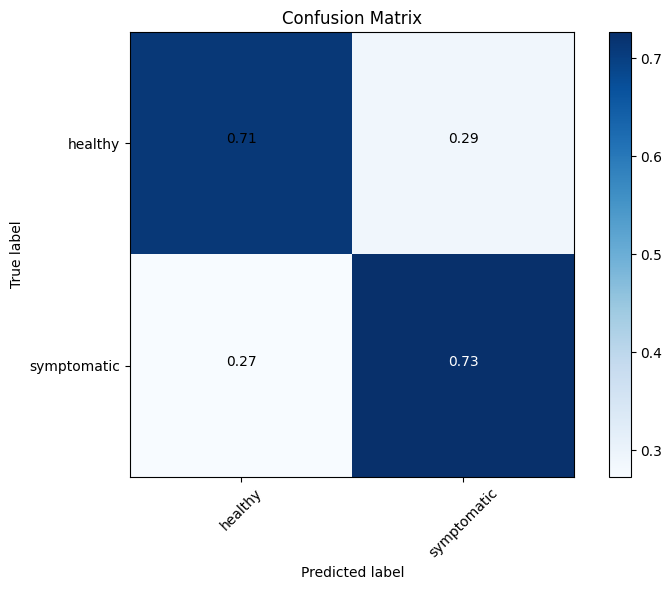

Saved: checkpoints/stage2_healthy_vs_symptomatic.pkl


In [4]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    'smote__k_neighbors': [3, 5],
    'pca__n_components':  [50, 80, 100],
    'clf__C':             [0.01, 0.1, 0.5, 1.0],
}
pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(k_neighbors=5, random_state=42)),
    ('pca',    PCA(n_components=80)),
    ('clf',    LogisticRegression(
                   class_weight='balanced',
                   max_iter=1000,
                   solver='lbfgs',
                   random_state=42
               ))
])
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid.fit(X_train, y_train)

print('Best params:', grid.best_params_)
clf_s2 = grid.best_estimator_
print(f'Train Accuracy: {clf_s2.score(X_train, y_train)*100:.2f} %')
print(f'Test Accuracy:  {clf_s2.score(X_test, y_test)*100:.2f} %')
predictions = clf_s2.predict(X_test)
print(classification_report(y_test, predictions, target_names=encoder.classes_))
plot_confusion_matrix(y_test, predictions, encoder.classes_)

joblib.dump({
    'clf':      clf_s2,
    'encoder':  encoder,
    'features': FEATURES
}, 'checkpoints/stage2_healthy_vs_symptomatic.pkl')
print('Saved: checkpoints/stage2_healthy_vs_symptomatic.pkl')